# Matrice transiliente de QdM 


## 0. SETUP COMMUN -- a completer une seule fois

In [1]:
#============================================================
#  SETUP COMMUN — pipeline large300 (RCEMIP Meso-NH)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import xarray as xr
import gc, os
from scipy.signal import detrend, hilbert
from scipy.ndimage import uniform_filter1d

plt.rcParams.update({'figure.dpi':120,'font.size':11,'axes.grid':True,
                     'grid.alpha':0.25,'image.cmap':'RdBu_r'})
Rd,Rv=287.05,461.5; EPSILON=Rd/Rv; g=9.81; KARMAN=0.4
Z_TOP_KM=15.0
DIR_3D,DIR_2D,DIR_1D='3D','2D','1D'
def path3d(v): return os.path.join(DIR_3D,f'MESONH_RCE_large300_3D_{v}.nc')
def path2d(v): return os.path.join(DIR_2D,f'MESONH_RCE_large300_2D_{v}.nc')
def path1d(v): return os.path.join(DIR_1D,f'MESONH_RCE_large300_1D_{v}.nc')
BLOC=2

_ds=xr.open_dataset(path3d('ua')); _da=_ds['ua']
dim_t,dim_z,dim_y,dim_x=_da.dims[:4]
n_t,n_z=_da.sizes[dim_t],_da.sizes[dim_z]; n_y,n_x=_da.sizes[dim_y],_da.sizes[dim_x]
_xv=_da[dim_x].values; dx=float(np.mean(np.diff(_xv))) if _xv.size>1 else 1000.0
if abs(dx)<=1.5: dx=1000.0
_ds.close(); del _ds,_da; gc.collect()
_ds1=xr.open_dataset(path1d('ua_avg')); alt=_ds1.altitude.values.astype(float).copy(); _ds1.close()
x=np.arange(n_x,dtype=float)*dx; zkm=alt/1000.0
mask_show=alt<=Z_TOP_KM*1000; m28=(alt>=2000)&(alt<=8000)

# fenetre stationnaire = toute la fenetre (RCE quasi-stationnaire, cf. runs precedents)
t_stat=0; idx_stat=slice(t_stat,None); n_stat=n_t-t_stat
dt_phys=6*3600.0                      # RCEMIP : snapshots 3D 6-horaires

# masques humide/sec (PRW)
ds_prw=xr.open_dataset(path2d('prw')); prw_all=ds_prw['prw'].load(); ds_prw.close()
prw_mean=prw_all.isel({dim_t:idx_stat}).mean(dim=dim_t)
PRW_SEUIL=float(np.median(prw_all.values.ravel()))
mh=(prw_mean.values>PRW_SEUIL); ms=~mh; del prw_all; gc.collect()

print(f'{n_t} t x {n_z} z x {n_y} y x {n_x} x | dx={dx:.0f}m | dt={dt_phys/3600:.0f}h')
print(f'altitude {alt[0]:.0f}-{alt[-1]:.0f}m | z[1]={alt[1]:.0f}m | fenetre {n_stat} pas = {n_stat*dt_phys/86400:.0f} j')
print(f'humide {mh.mean()*100:.0f}% / sec {ms.mean()*100:.0f}% (seuil PRW={PRW_SEUIL:.1f})')


100 t x 74 z x 128 y x 2000 x | dx=1000m | dt=6h
altitude 0-32500m | z[1]=37m | fenetre 100 pas = 25 j
humide 43% / sec 57% (seuil PRW=30.4)


In [2]:
#============================================================
#  CHAMPS DE BASE : rho0(z), profils ET champs (z,t)
#   - profils moyens : flux_tot, ubar, dudz, uw       (1D, pour §1-§5-§6)
#   - champs (z,t)   : flux_zt, ubar_zt, wbar_zt, ...  (2D, pour le contexte)
# ============================================================
# rho0(z)
rho0_sum=np.zeros(n_z); n_rho=0
ds_ta=xr.open_dataset(path3d('ta')); ds_pa=xr.open_dataset(path3d('pa')); ds_hus=xr.open_dataset(path3d('hus'))
for t0 in range(t_stat,n_t,BLOC):
    t1=min(t0+BLOC,n_t); sl={dim_t:slice(t0,t1)}
    T=ds_ta['ta'].isel(sl).values; p=ds_pa['pa'].isel(sl).values; qv=ds_hus['hus'].isel(sl).values
    Tv=T*(1+qv/EPSILON)/(1+qv); rho=p/(Rd*Tv)
    rho0_sum+=rho.mean(axis=(0,2,3))*(t1-t0); n_rho+=(t1-t0)
    del T,p,qv,Tv,rho; gc.collect()
ds_ta.close(); ds_pa.close(); ds_hus.close(); rho0=rho0_sum/n_rho

# champs (z,t) : flux, ubar, wbar   (niveau par niveau)
flux_zt=np.zeros((n_z,n_stat)); ubar_zt=np.zeros((n_z,n_stat)); wbar_zt=np.zeros((n_z,n_stat))
ds_u=xr.open_dataset(path3d('ua')); ds_w=xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    u=ds_u['ua'].isel({dim_t:idx_stat,dim_z:iz}).values
    w=ds_w['wa'].isel({dim_t:idx_stat,dim_z:iz}).values
    ub=u.mean(axis=(1,2)); wb=w.mean(axis=(1,2))
    up=u-ub[:,None,None]; wp=w-wb[:,None,None]
    flux_zt[iz]=rho0[iz]*(up*wp).mean(axis=(1,2)); ubar_zt[iz]=ub; wbar_zt[iz]=wb
    del u,w,up,wp; gc.collect()
ds_u.close(); ds_w.close(); gc.collect()

# profils moyens (moyenne temporelle des champs zt)
flux_tot=flux_zt.mean(1); ubar=ubar_zt.mean(1); wbar=wbar_zt.mean(1)
uw=flux_tot/rho0; dudz=np.gradient(ubar,alt); d2udz2=np.gradient(dudz,alt)
# derivees des champs zt (pour le contexte dynamique)
dudz_zt=np.gradient(ubar_zt,alt,axis=0); d2udz2_zt=np.gradient(dudz_zt,alt,axis=0)
uw_zt=flux_zt/rho0[:,None]
print(f'rho0 surface={rho0[0]:.3f} | ~10km={rho0[np.argmin(np.abs(alt-10000))]:.3f} kg/m3')
print('profils (flux_tot,ubar,dudz,uw) et champs (flux_zt,ubar_zt,...) prets.')


rho0 surface=1.183 | ~10km=0.410 kg/m3
profils (flux_tot,ubar,dudz,uw) et champs (flux_zt,ubar_zt,...) prets.


In [3]:
# --- Vérification des objets hérités du pipeline (setup notebook 8) ---
import numpy as np, matplotlib.pyplot as plt, gc
from numpy.linalg import lstsq

_required = ['rho0','alt','flux_zt','ubar_zt','wbar_zt','mh','ms',
             'dt_phys','n_stat','n_z','dim_t','dim_z','idx_stat']
_g = globals()
_missing = [k for k in _required if k not in _g]
assert not _missing, f"Objets manquants -> relance le setup large300 : {_missing}"

zkm   = alt/1000.0
Z_LO, Z_HI = 2000.0, 18000.0                 # fenêtre d'étude (2-18 km, comme la régression synthèse)
band  = (alt>=Z_LO)&(alt<=Z_HI)
iz_band = np.where(band)[0]

# profils moyens temporels (au cas où non définis)
flux_tot = flux_zt.mean(1)
ubar     = ubar_zt.mean(1)
dudz     = np.gradient(ubar, alt)
d2udz2   = np.gradient(dudz, alt)
uw       = flux_tot/rho0

print(f"OK. {n_z} niveaux, fenêtre 2-18 km = {band.sum()} niveaux, {n_stat} pas de temps.")
print(f"flux_tot min={flux_tot.min():.2e} @ {alt[np.argmin(flux_tot)]:.0f} m")


OK. 74 niveaux, fenêtre 2-18 km = 33 niveaux, 100 pas de temps.
flux_tot min=-1.17e-02 @ 4500 m


In [4]:
# ---- dy manquant : derive depuis la coordonnee dim_y de 'ua' -----------
_ds = xr.open_dataset(path3d('ua'))
_yv = _ds[dim_y].values.astype(float)
dy = float(np.mean(np.diff(_yv))) if _yv.size > 1 else dx
if abs(dy) <= 1.5:
    dy = dx      # coordonnee en km ou en indice -> on retombe sur dx (suppose grille reguliere)
_ds.close(); del _ds, _yv
gc.collect()

print(f"dy derive = {dy:.0f} m")

dy derive = 1000 m


In [5]:
zkm = alt / 1000.0

     

# ---- controle : verifie que le setup est complet AVANT d'aller plus loin ----
_required = ['path3d', 'path2d', 'dim_t', 'dim_z', 'dim_y', 'dim_x',
             'idx_stat', 'n_z', 'n_stat', 'n_x', 'n_y', 'rho0', 'alt', 'dx', 'dy', 'dt_phys']
_missing = [v for v in _required if v not in globals()]
if _missing:
    raise NameError(
        "Setup incomplet -- variables manquantes : " + ", ".join(_missing) +
        "\n=> colle ton bloc habituel dans la cellule SETUP ci-dessus, puis relance."
    )
print("Setup OK :")
print(f"  n_z={n_z}  n_stat={n_stat}  n_y={n_y}  n_x={n_x}")
print(f"  dx={dx:.0f} m   dy={dy:.0f} m   dt_phys={dt_phys/3600:.1f} h")
print(f"  alt : {alt.min():.0f} -> {alt.max():.0f} m   ({n_z} niveaux)")

     


Setup OK :
  n_z=74  n_stat=100  n_y=128  n_x=2000
  dx=1000 m   dy=1000 m   dt_phys=6.0 h
  alt : 0 -> 32500 m   (74 niveaux)


In [6]:
# ---- normalise idx_stat en tableau d'indices, quel que soit son type -----
if isinstance(idx_stat, slice):
    _ds_tmp = xr.open_dataset(path3d('ua'))
    _n_t_total = _ds_tmp.sizes[dim_t]
    _ds_tmp.close()
    idx_stat = np.arange(*idx_stat.indices(_n_t_total))
else:
    idx_stat = np.asarray(idx_stat)

n_stat = idx_stat.size   # recalcule pour rester coherent avec le idx_stat normalise

print(f"idx_stat normalise en tableau : {idx_stat.size} indices, de {idx_stat.min()} a {idx_stat.max()}")

idx_stat normalise en tableau : 100 indices, de 0 a 99


## 1. Romps et Kuang





  t=0/100
  t=20/100
  t=40/100
  t=60/100
  t=80/100
b_qdm : min -8.00e-09  max 1.33e-10  (pas de contrainte de signe attendue, contrairement a la version masse)


/tmp/ipykernel_60181/614027777.py:89: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im = ax.pcolormesh(zb/1e3, zb/1e3, b_qdm, cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='auto')


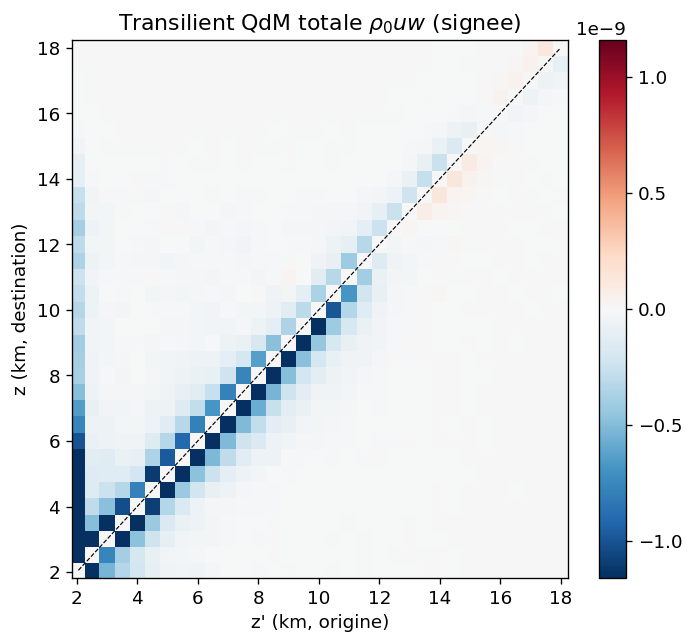

In [13]:
# ============================================================
#  TRANSILIENT QdM — B_qdm[dest,orig] = rho0*u*w SIGNE transporte par
#  des segments verticaux coherents (meme decoupage que la version masse,
#  mais on garde la quantite de mouvement reelle, pas |flux de masse|)
# ============================================================
def build_transilient_qdm(S, U, W, rho_col, min_run=2):
    """
    S : (nz,ny,nx) signe de w seuille (+1/-1/0), un seul pas de temps
    U : (nz,ny,nx) vent horizontal u, meme instant
    W : (nz,ny,nx) vitesse verticale w, meme instant
    rho_col : (nz,) rho0 sur la grille reduite
    """
    nz, ny, nx = S.shape
    nonzero = S != 0
    start = np.zeros_like(nonzero)
    start[0] = nonzero[0]
    start[1:] = nonzero[1:] & (S[1:] != S[:-1])
    seg_id = np.cumsum(start, axis=0) - 1
    seg_id = np.where(nonzero, seg_id, -1)

    flux_sum = np.zeros((nz, ny, nx))
    count    = np.zeros((nz, ny, nx), dtype=np.int32)
    zmin     = np.full((nz, ny, nx), nz, dtype=np.int32)
    zmax     = np.full((nz, ny, nx), -1, dtype=np.int32)
    sign_of  = np.zeros((nz, ny, nx))
    yy, xx = np.meshgrid(np.arange(ny), np.arange(nx), indexing='ij')

    for k in range(nz):
        valid = nonzero[k]
        if not valid.any():
            continue
        sid = seg_id[k][valid]
        y_v, x_v = yy[valid], xx[valid]
        val = rho_col[k] * U[k][valid] * W[k][valid]     # <-- SIGNE, plus de abs()
        np.add.at(flux_sum, (sid, y_v, x_v), val)
        np.add.at(count,    (sid, y_v, x_v), 1)
        np.minimum.at(zmin, (sid, y_v, x_v), k)
        np.maximum.at(zmax, (sid, y_v, x_v), k)
        sign_of[sid, y_v, x_v] = S[k][valid]

    ok = count >= min_run
    B = np.zeros((nz, nz))
    if not ok.any():
        return B
    s_idx  = sign_of[ok]; zlo = zmin[ok]; zhi = zmax[ok]
    meanfl = flux_sum[ok] / np.maximum(count[ok], 1)
    dest = np.where(s_idx > 0, zhi, zlo)
    orig = np.where(s_idx > 0, zlo, zhi)
    np.add.at(B, (dest, orig), meanfl)
    return B


def accumulate_transilient_qdm(ib, idx_time, W_SEUIL=0.3, MIN_RUN=2, verbose=True):
    zb = alt[ib]; rb = rho0[ib]; nb = ib.size
    B = np.zeros((nb, nb))
    ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
    t_global = idx_stat[idx_time]
    for n, it in enumerate(t_global):
        u = ds_u['ua'].isel({dim_t: it, dim_z: ib}).values.astype(np.float32)
        w = ds_w['wa'].isel({dim_t: it, dim_z: ib}).values.astype(np.float32)
        S = np.sign(w); S[np.abs(w) < W_SEUIL] = 0
        B += build_transilient_qdm(S, u, w, rb, min_run=MIN_RUN)
        del u, w, S
        if n % 20 == 0:
            gc.collect()
            if verbose: print(f"  t={n}/{len(t_global)}")
    ds_u.close(); ds_w.close(); gc.collect()
    return B, zb, rb, nb


# ============================================================
#  EXECUTION
# ============================================================
Z_LO, Z_HI = 2000.0, 18000.0
band = (alt >= Z_LO) & (alt <= Z_HI); ib = np.where(band)[0]
W_SEUIL, MIN_RUN = 0.3, 2

Bqdm, zb, rb, nb = accumulate_transilient_qdm(ib, np.arange(n_stat), W_SEUIL=W_SEUIL, MIN_RUN=MIN_RUN)

dz_b = np.gradient(zb)
norm = n_stat * n_y * n_x * np.outer(dz_b, dz_b)
b_qdm = Bqdm / np.maximum(norm, 1e-30)

print(f"b_qdm : min {b_qdm.min():.2e}  max {b_qdm.max():.2e}  "
      f"(pas de contrainte de signe attendue, contrairement a la version masse)")

fig, ax = plt.subplots(figsize=(6, 5.5))
vmax = np.percentile(np.abs(b_qdm), 98)
im = ax.pcolormesh(zb/1e3, zb/1e3, b_qdm, cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='auto')
ax.plot(zb/1e3, zb/1e3, 'k--', lw=.7)
ax.set_xlabel("z' (km, origine)"); ax.set_ylabel('z (km, destination)')
ax.set_title(r"Transilient QdM totale $\rho_0 u w$ (signee)")
fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

  t=0/100
  t=20/100
  t=40/100
  t=60/100
  t=80/100
b_qdm : min -3.99e-09  max 2.45e-09  (pas de contrainte de signe attendue, contrairement a la version masse)


/tmp/ipykernel_60181/2455759035.py:89: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im = ax.pcolormesh(zb/1e3, zb/1e3, b_qdm, cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='auto')


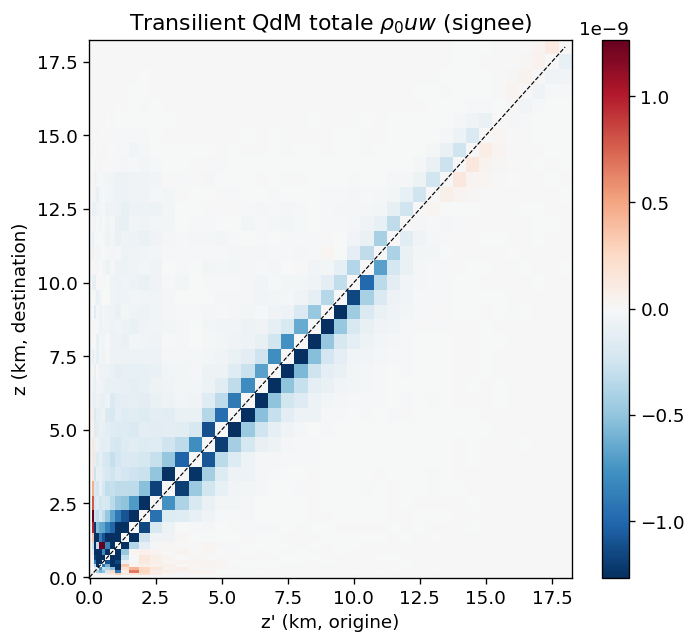

In [12]:
# ============================================================
#  TRANSILIENT QdM — B_qdm[dest,orig] = rho0*u*w SIGNE transporte par
#  des segments verticaux coherents (meme decoupage que la version masse,
#  mais on garde la quantite de mouvement reelle, pas |flux de masse|)
# ============================================================
def build_transilient_qdm(S, U, W, rho_col, min_run=2):
    """
    S : (nz,ny,nx) signe de w seuille (+1/-1/0), un seul pas de temps
    U : (nz,ny,nx) vent horizontal u, meme instant
    W : (nz,ny,nx) vitesse verticale w, meme instant
    rho_col : (nz,) rho0 sur la grille reduite
    """
    nz, ny, nx = S.shape
    nonzero = S != 0
    start = np.zeros_like(nonzero)
    start[0] = nonzero[0]
    start[1:] = nonzero[1:] & (S[1:] != S[:-1])
    seg_id = np.cumsum(start, axis=0) - 1
    seg_id = np.where(nonzero, seg_id, -1)

    flux_sum = np.zeros((nz, ny, nx))
    count    = np.zeros((nz, ny, nx), dtype=np.int32)
    zmin     = np.full((nz, ny, nx), nz, dtype=np.int32)
    zmax     = np.full((nz, ny, nx), -1, dtype=np.int32)
    sign_of  = np.zeros((nz, ny, nx))
    yy, xx = np.meshgrid(np.arange(ny), np.arange(nx), indexing='ij')

    for k in range(nz):
        valid = nonzero[k]
        if not valid.any():
            continue
        sid = seg_id[k][valid]
        y_v, x_v = yy[valid], xx[valid]
        val = rho_col[k] * U[k][valid] * W[k][valid]     # <-- SIGNE, plus de abs()
        np.add.at(flux_sum, (sid, y_v, x_v), val)
        np.add.at(count,    (sid, y_v, x_v), 1)
        np.minimum.at(zmin, (sid, y_v, x_v), k)
        np.maximum.at(zmax, (sid, y_v, x_v), k)
        sign_of[sid, y_v, x_v] = S[k][valid]

    ok = count >= min_run
    B = np.zeros((nz, nz))
    if not ok.any():
        return B
    s_idx  = sign_of[ok]; zlo = zmin[ok]; zhi = zmax[ok]
    meanfl = flux_sum[ok] / np.maximum(count[ok], 1)
    dest = np.where(s_idx > 0, zhi, zlo)
    orig = np.where(s_idx > 0, zlo, zhi)
    np.add.at(B, (dest, orig), meanfl)
    return B


def accumulate_transilient_qdm(ib, idx_time, W_SEUIL=0.3, MIN_RUN=2, verbose=True):
    zb = alt[ib]; rb = rho0[ib]; nb = ib.size
    B = np.zeros((nb, nb))
    ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
    t_global = idx_stat[idx_time]
    for n, it in enumerate(t_global):
        u = ds_u['ua'].isel({dim_t: it, dim_z: ib}).values.astype(np.float32)
        w = ds_w['wa'].isel({dim_t: it, dim_z: ib}).values.astype(np.float32)
        S = np.sign(w); S[np.abs(w) < W_SEUIL] = 0
        B += build_transilient_qdm(S, u, w, rb, min_run=MIN_RUN)
        del u, w, S
        if n % 20 == 0:
            gc.collect()
            if verbose: print(f"  t={n}/{len(t_global)}")
    ds_u.close(); ds_w.close(); gc.collect()
    return B, zb, rb, nb


# ============================================================
#  EXECUTION
# ============================================================
Z_LO, Z_HI = 0.0, 18000.0
band = (alt >= Z_LO) & (alt <= Z_HI); ib = np.where(band)[0]
W_SEUIL, MIN_RUN = 0.3, 2

Bqdm, zb, rb, nb = accumulate_transilient_qdm(ib, np.arange(n_stat), W_SEUIL=W_SEUIL, MIN_RUN=MIN_RUN)

dz_b = np.gradient(zb)
norm = n_stat * n_y * n_x * np.outer(dz_b, dz_b)
b_qdm = Bqdm / np.maximum(norm, 1e-30)

print(f"b_qdm : min {b_qdm.min():.2e}  max {b_qdm.max():.2e}  "
      f"(pas de contrainte de signe attendue, contrairement a la version masse)")

fig, ax = plt.subplots(figsize=(6, 5.5))
vmax = np.percentile(np.abs(b_qdm), 98)
im = ax.pcolormesh(zb/1e3, zb/1e3, b_qdm, cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='auto')
ax.plot(zb/1e3, zb/1e3, 'k--', lw=.7)
ax.set_xlabel("z' (km, origine)"); ax.set_ylabel('z (km, destination)')
ax.set_title(r"Transilient QdM totale $\rho_0 u w$ (signee)")
fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

  t=0/100
  t=20/100
  t=40/100
  t=60/100
  t=80/100
b_qdm (brut) : min -9.774e+03  max 2.085e+03


/tmp/ipykernel_60181/3623277423.py:80: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im = ax.pcolormesh(zb/1e3, zb/1e3, b_qdm, cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='auto')


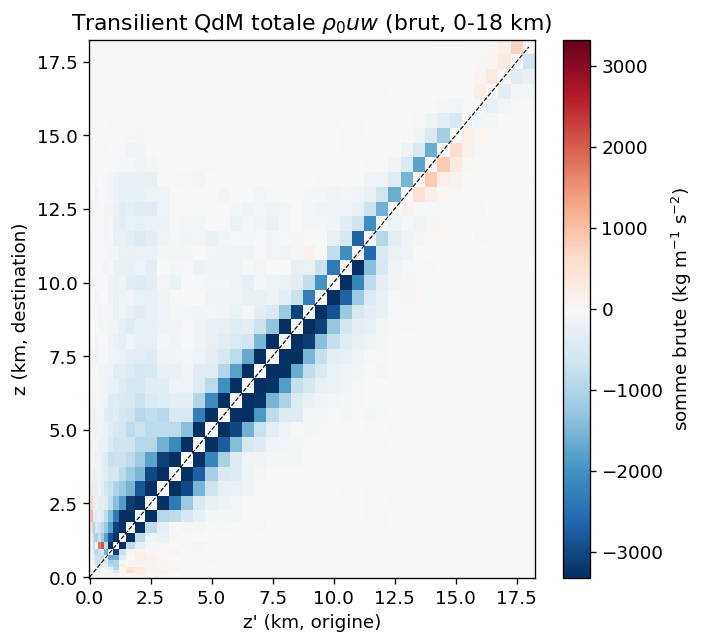

In [15]:
# ============================================================
#  TRANSILIENT QdM TOTALE — B_qdm[dest,orig] = rho0*u*w SIGNE transporte
#  par des segments verticaux coherents, bande 0-18 km, SANS normalisation
# ============================================================
import numpy as np, xarray as xr, gc
import matplotlib.pyplot as plt

def build_transilient_qdm(S, U, W, rho_col, min_run=2):
    nz, ny, nx = S.shape
    nonzero = S != 0
    start = np.zeros_like(nonzero)
    start[0] = nonzero[0]
    start[1:] = nonzero[1:] & (S[1:] != S[:-1])
    seg_id = np.cumsum(start, axis=0) - 1
    seg_id = np.where(nonzero, seg_id, -1)

    flux_sum = np.zeros((nz, ny, nx))
    count    = np.zeros((nz, ny, nx), dtype=np.int32)
    zmin     = np.full((nz, ny, nx), nz, dtype=np.int32)
    zmax     = np.full((nz, ny, nx), -1, dtype=np.int32)
    sign_of  = np.zeros((nz, ny, nx))
    yy, xx = np.meshgrid(np.arange(ny), np.arange(nx), indexing='ij')

    for k in range(nz):
        valid = nonzero[k]
        if not valid.any():
            continue
        sid = seg_id[k][valid]
        y_v, x_v = yy[valid], xx[valid]
        val = rho_col[k] * U[k][valid] * W[k][valid]     # signe, quantite de mouvement
        np.add.at(flux_sum, (sid, y_v, x_v), val)
        np.add.at(count,    (sid, y_v, x_v), 1)
        np.minimum.at(zmin, (sid, y_v, x_v), k)
        np.maximum.at(zmax, (sid, y_v, x_v), k)
        sign_of[sid, y_v, x_v] = S[k][valid]

    ok = count >= min_run
    B = np.zeros((nz, nz))
    if not ok.any():
        return B
    s_idx  = sign_of[ok]; zlo = zmin[ok]; zhi = zmax[ok]
    meanfl = flux_sum[ok] / np.maximum(count[ok], 1)
    dest = np.where(s_idx > 0, zhi, zlo)
    orig = np.where(s_idx > 0, zlo, zhi)
    np.add.at(B, (dest, orig), meanfl)
    return B


def accumulate_transilient_qdm(ib, idx_time, W_SEUIL=0.3, MIN_RUN=2, verbose=True):
    zb = alt[ib]; rb = rho0[ib]; nb = ib.size
    B = np.zeros((nb, nb))
    ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
    t_global = idx_stat[idx_time]
    for n, it in enumerate(t_global):
        u = ds_u['ua'].isel({dim_t: it, dim_z: ib}).values.astype(np.float32)
        w = ds_w['wa'].isel({dim_t: it, dim_z: ib}).values.astype(np.float32)
        S = np.sign(w); S[np.abs(w) < W_SEUIL] = 0
        B += build_transilient_qdm(S, u, w, rb, min_run=MIN_RUN)
        del u, w, S
        if n % 20 == 0:
            gc.collect()
            if verbose: print(f"  t={n}/{len(t_global)}")
    ds_u.close(); ds_w.close(); gc.collect()
    return B, zb, rb, nb


# ============================================================
#  EXECUTION — bande 0-18 km
# ============================================================
Z_LO, Z_HI = 0.0, 18000.0
band = (alt >= Z_LO) & (alt <= Z_HI); ib = np.where(band)[0]
W_SEUIL, MIN_RUN = 0.3, 2

b_qdm, zb, rb, nb = accumulate_transilient_qdm(ib, np.arange(n_stat), W_SEUIL=W_SEUIL, MIN_RUN=MIN_RUN)

print(f"b_qdm (brut) : min {b_qdm.min():.3e}  max {b_qdm.max():.3e}")

fig, ax = plt.subplots(figsize=(6, 5.5))
vmax = np.percentile(np.abs(b_qdm), 98)
im = ax.pcolormesh(zb/1e3, zb/1e3, b_qdm, cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='auto')
ax.plot(zb/1e3, zb/1e3, 'k--', lw=.7)
ax.set_xlabel("z' (km, origine)"); ax.set_ylabel('z (km, destination)')
ax.set_title(r"Transilient QdM totale $\rho_0 u w$ (brut, 0-18 km)")
fig.colorbar(im, ax=ax, label='somme brute (kg m$^{-1}$ s$^{-2}$)')
plt.tight_layout(); plt.show()


  t=0/100
  t=20/100
  t=40/100
  t=60/100
  t=80/100
b_T2 (brut) : min -1.045e+04  max 4.058e+03


/tmp/ipykernel_60181/33745146.py:85: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im = ax.pcolormesh(zb2/1e3, zb2/1e3, b_T2, cmap='RdBu_r', vmin=-vmax2, vmax=vmax2, shading='auto')


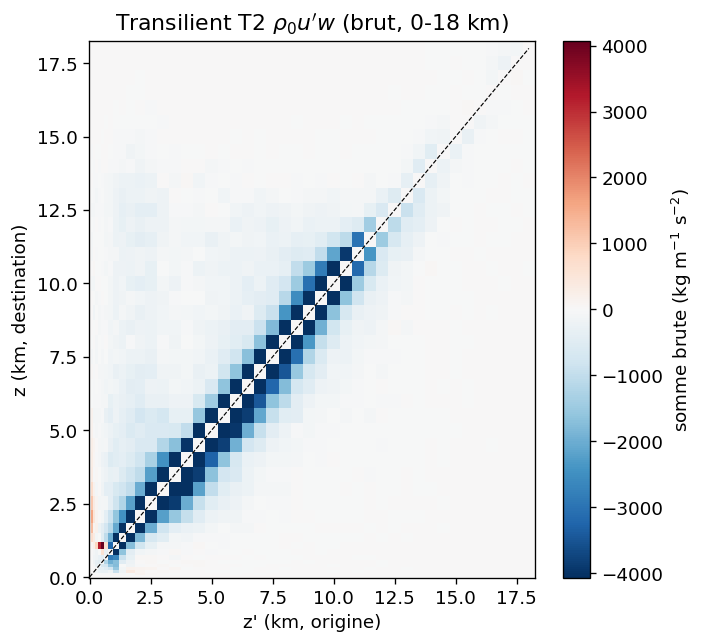


Reserve methodologique :
- u' est ici l'anomalie au vent moyen DOMAINE au niveau z, instant t,
  PAS la decomposition up/down/env de ton rapport (§6.3). C'est un proxy.


In [16]:
# ============================================================
#  TRANSILIENT T2 — B_T2[dest,orig] = rho0*u'*w SIGNE transporte par les
#  memes segments coherents, u' = u - <u>(z,t) anomalie locale,
#  bande 0-18 km, SANS normalisation
#  (proxy operationnel de T2 : anomalie au vent moyen DOMAINE, pas la
#   decomposition up/down/env exacte du rapport)
# ============================================================
import numpy as np, xarray as xr, gc
import matplotlib.pyplot as plt

def build_transilient_T2(S, Uprime, W, rho_col, min_run=2):
    nz, ny, nx = S.shape
    nonzero = S != 0
    start = np.zeros_like(nonzero)
    start[0] = nonzero[0]
    start[1:] = nonzero[1:] & (S[1:] != S[:-1])
    seg_id = np.cumsum(start, axis=0) - 1
    seg_id = np.where(nonzero, seg_id, -1)

    flux_sum = np.zeros((nz, ny, nx))
    count    = np.zeros((nz, ny, nx), dtype=np.int32)
    zmin     = np.full((nz, ny, nx), nz, dtype=np.int32)
    zmax     = np.full((nz, ny, nx), -1, dtype=np.int32)
    sign_of  = np.zeros((nz, ny, nx))
    yy, xx = np.meshgrid(np.arange(ny), np.arange(nx), indexing='ij')

    for k in range(nz):
        valid = nonzero[k]
        if not valid.any():
            continue
        sid = seg_id[k][valid]
        y_v, x_v = yy[valid], xx[valid]
        val = rho_col[k] * Uprime[k][valid] * W[k][valid]   # u' au lieu de u
        np.add.at(flux_sum, (sid, y_v, x_v), val)
        np.add.at(count,    (sid, y_v, x_v), 1)
        np.minimum.at(zmin, (sid, y_v, x_v), k)
        np.maximum.at(zmax, (sid, y_v, x_v), k)
        sign_of[sid, y_v, x_v] = S[k][valid]

    ok = count >= min_run
    B = np.zeros((nz, nz))
    if not ok.any():
        return B
    s_idx  = sign_of[ok]; zlo = zmin[ok]; zhi = zmax[ok]
    meanfl = flux_sum[ok] / np.maximum(count[ok], 1)
    dest = np.where(s_idx > 0, zhi, zlo)
    orig = np.where(s_idx > 0, zlo, zhi)
    np.add.at(B, (dest, orig), meanfl)
    return B


def accumulate_transilient_T2(ib, idx_time, W_SEUIL=0.3, MIN_RUN=2, verbose=True):
    zb = alt[ib]; rb = rho0[ib]; nb = ib.size
    B = np.zeros((nb, nb))
    ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
    t_global = idx_stat[idx_time]
    for n, it in enumerate(t_global):
        u = ds_u['ua'].isel({dim_t: it, dim_z: ib}).values.astype(np.float32)
        w = ds_w['wa'].isel({dim_t: it, dim_z: ib}).values.astype(np.float32)
        ubar_t = u.mean(axis=(1, 2), keepdims=True)     # <u>(z) a cet instant
        uprime = u - ubar_t
        S = np.sign(w); S[np.abs(w) < W_SEUIL] = 0
        B += build_transilient_T2(S, uprime, w, rb, min_run=MIN_RUN)
        del u, w, uprime, ubar_t, S
        if n % 20 == 0:
            gc.collect()
            if verbose: print(f"  t={n}/{len(t_global)}")
    ds_u.close(); ds_w.close(); gc.collect()
    return B, zb, rb, nb


# ============================================================
#  EXECUTION — bande 0-18 km
# ============================================================
Z_LO, Z_HI = 0.0, 18000.0
band = (alt >= Z_LO) & (alt <= Z_HI); ib = np.where(band)[0]
W_SEUIL, MIN_RUN = 0.3, 2

b_T2, zb2, rb2, nb2 = accumulate_transilient_T2(ib, np.arange(n_stat), W_SEUIL=W_SEUIL, MIN_RUN=MIN_RUN)

print(f"b_T2 (brut) : min {b_T2.min():.3e}  max {b_T2.max():.3e}")

fig, ax = plt.subplots(figsize=(6, 5.5))
vmax2 = np.percentile(np.abs(b_T2), 98)
im = ax.pcolormesh(zb2/1e3, zb2/1e3, b_T2, cmap='RdBu_r', vmin=-vmax2, vmax=vmax2, shading='auto')
ax.plot(zb2/1e3, zb2/1e3, 'k--', lw=.7)
ax.set_xlabel("z' (km, origine)"); ax.set_ylabel('z (km, destination)')
ax.set_title(r"Transilient T2 $\rho_0 u' w$ (brut, 0-18 km)")
fig.colorbar(im, ax=ax, label='somme brute (kg m$^{-1}$ s$^{-2}$)')
plt.tight_layout(); plt.show()

print("\nReserve methodologique :")
print("- u' est ici l'anomalie au vent moyen DOMAINE au niveau z, instant t,")
print("  PAS la decomposition up/down/env de ton rapport (§6.3). C'est un proxy.")